Sources:
(https://www.rdkit.org/docs/source/rdkit.Chem.rdMolDescriptors.html)
https://www.rdkit.org/docs/GettingStartedInPython.html#substructure-searches

In [15]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, GraphDescriptors, rdMolDescriptors
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#import linker data and resolve UnicodeDecodeError
linker = pd.read_csv('data/linkers.csv', encoding = 'latin1')
#convert SMILES to RDKit, remove invalid entries
linker = linker.assign(molecule = linker['smiles'].apply(Chem.MolFromSmiles)).query('molecule.notnull()')
#create canonical smiles so that all versions of same molecule maps to the same SMILES string
linker['smiles'] = linker['molecule'].apply(Chem.MolToSmiles)
#remove duplicate values

#use one hot encoding -- needed for later
linker_encoder = OneHotEncoder(sparse_output = False)
encoded_linker = linker_encoder.fit_transform(linker[['source']])
encoded = pd.DataFrame(encoded_linker, columns = linker_encoder.get_feature_names_out(['source']))
#join both the linker and OHE data
concat_linker = pd.concat([linker.reset_index(drop = True), encoded.reset_index(drop = True)], axis = 1)
concat_linker.head()

,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,Molecular Weight,K-means,scaffold_smiles,source,molecule,source_train,source_val
0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,C=CCOC(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(...,3.508295,204.30,0.036588,4.5636,689.72,12,O=C(CCc1ccccc1)NCC(=O)Nc1ccc(COC(=O)Oc2ccccc2)cc1,train,<rdkit.Chem.rdchem.Mol object at 0x000001C173D...,1.0,0.0
1,1,1,1,6-Maleimidohexanoic acid N-hydroxysuccinimide ...,O=C(CCCCCN1C(=O)C=CC1=O)ON1C(=O)CCC1=O,2.676214,101.06,0.487410,0.0790,308.29,4,O=C(CCCCCN1C(=O)C=CC1=O)ON1C(=O)CCC1=O,train,<rdkit.Chem.rdchem.Mol object at 0x000001C173D...,1.0,0.0
2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.338596,171.88,0.163403,3.6140,601.70,12,O=C(CNC(=O)OCC1c2ccccc2-c2ccccc21)NCC(=O)Nc1cc...,train,<rdkit.Chem.rdchem.Mol object at 0x000001C173D...,1.0,0.0
3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.753739,230.32,0.030495,5.7455,766.81,12,O=C(CNC(=O)OCC1c2ccccc2-c2ccccc21)NCC(=O)Nc1cc...,train,<rdkit.Chem.rdchem.Mol object at 0x000001C173D...,1.0,0.0
4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@H](NC(=O)CCCCCN1C(=O)C=CC1=O)C(=O)N[C@...,3.796268,258.47,0.032958,2.8084,737.77,12,O=C(CCCCCN1C(=O)C=CC1=O)NCC(=O)NCC(=O)Nc1ccc(C...,train,<rdkit.Chem.rdchem.Mol object at 0x000001C173D...,1.0,0.0


In [3]:
#get the SMARTS syntax for hydrophilic functional groups -- going to try to find more that are important
hg = {'hydroxyl': Chem.MolFromSmarts('[OX2;H]'), 'carboxyl' : Chem.MolFromSmarts('C(=O)[OX2H]'), 'amino': Chem.MolFromSmarts('[NX3;H2;!$(NC=O)]'), 'phosphate': Chem.MolFromSmarts('[PX4;!$(P(=O)(O)(O))]')}

def smarts(func_group):
    
    valid_smarts = {}
    for name, molecule in func_group.items():
        if molecule:
            valid_smarts[name] = molecule
        else:
            print(f'Invalid')
        
    return valid_smarts

#use SMARTS on a molecule

def run_smarts(molecule, pattern):
    return {name: int(molecule.HasSubstructMatch(p)) for name, p in pattern.items()}

# ADDED - Sana:
def smarts_count (molecule, pattern):
    counts = {}
    for name, pat in pattern.items():
        if molecule is not None:
            matches = molecule.GetSubstructMatches(pat)
            counts[name] = len(matches)
        else:
            counts[name] = 0
    return counts

#apply to all
hydrophilic_groups = linker['molecule'].apply(lambda mol: run_smarts(mol, hg))

#create DataFrame
hydrophilic = pd.DataFrame(list(hydrophilic_groups), index = linker.index)
#when this re-runs, duplicate columns are made.. this will prevent those from popping up
linker = linker.drop(columns = ['hydroxyl', 'carboxyl', 'amino', 'phosphate'], errors = 'ignore')
#join both dataframes
linker = linker.join(hydrophilic)

################################################################################################
#ADDED - Sana
################################################################################################
hydrophilic_counts = linker['molecule'].apply(lambda mol: smarts_count(mol, hg))

#create DataFrame
hydrophilic_counts_df = pd.DataFrame(list(hydrophilic_counts), index=linker.index)
hydrophilic_counts_df = hydrophilic_counts_df.add_suffix('_count') # add suffix to column names

#join count columns
linker = linker.join(hydrophilic_counts_df)
linker.head()


,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,Molecular Weight,...,source,molecule,hydroxyl,carboxyl,amino,phosphate,hydroxyl_count,carboxyl_count,amino_count,phosphate_count
0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,C=CCOC(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(...,3.508295,204.30,0.036588,4.5636,689.72,...,train,<rdkit.Chem.rdchem.Mol object at 0x000001C173D...,0,0,0,0,0,0,0,0
1,1,1,1,6-Maleimidohexanoic acid N-hydroxysuccinimide ...,O=C(CCCCCN1C(=O)C=CC1=O)ON1C(=O)CCC1=O,2.676214,101.06,0.487410,0.0790,308.29,...,train,<rdkit.Chem.rdchem.Mol object at 0x000001C173D...,0,0,0,0,0,0,0,0
2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.338596,171.88,0.163403,3.6140,601.70,...,train,<rdkit.Chem.rdchem.Mol object at 0x000001C173D...,1,0,0,0,1,0,0,0
3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.753739,230.32,0.030495,5.7455,766.81,...,train,<rdkit.Chem.rdchem.Mol object at 0x000001C173D...,0,0,0,0,0,0,0,0
4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@H](NC(=O)CCCCCN1C(=O)C=CC1=O)C(=O)N[C@...,3.796268,258.47,0.032958,2.8084,737.77,...,train,<rdkit.Chem.rdchem.Mol object at 0x000001C173D...,0,0,0,0,0,0,0,0


In [17]:
#get number of H donors and acceptors.. important for linker-payload interactions
#get FractionCSP3 and number of rotatable bonds to assess linker flexibility. important in different contexts
#get LabuteASA (approximate surface area) of a molecule, important in regards to solubility

linker['num_h_donors'] = linker['molecule'].apply(Descriptors.NumHDonors)
linker['num_h_acceptors'] = linker['molecule'].apply(Descriptors.NumHAcceptors)
linker['FractionCSP3'] = linker['molecule'].apply(Descriptors.FractionCSP3)
linker['num_rot_bonds'] = linker['molecule'].apply(Descriptors.NumRotatableBonds)
linker['Surface Area'] = linker['molecule'].apply(rdMolDescriptors.CalcLabuteASA)

linker.head()

,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,Molecular Weight,...,phosphate,hydroxyl_count,carboxyl_count,amino_count,phosphate_count,num_h_donors,num_h_acceptors,FractionCSP3,num_rot_bonds,Surface Area
0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,C=CCOC(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(...,3.508295,204.30,0.036588,4.5636,689.72,...,0,0,0,0,0,4,10,0.285714,18,288.060675
1,1,1,1,6-Maleimidohexanoic acid N-hydroxysuccinimide ...,O=C(CCCCCN1C(=O)C=CC1=O)ON1C(=O)CCC1=O,2.676214,101.06,0.487410,0.0790,308.29,...,0,0,0,0,0,0,6,0.500000,7,126.177095
2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.338596,171.88,0.163403,3.6140,601.70,...,0,1,0,0,0,6,6,0.333333,13,256.107099
3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.753739,230.32,0.030495,5.7455,766.81,...,0,0,0,0,0,5,10,0.275000,16,321.776490
4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@H](NC(=O)CCCCCN1C(=O)C=CC1=O)C(=O)N[C@...,3.796268,258.47,0.032958,2.8084,737.77,...,0,0,0,0,0,5,11,0.400000,20,304.496626


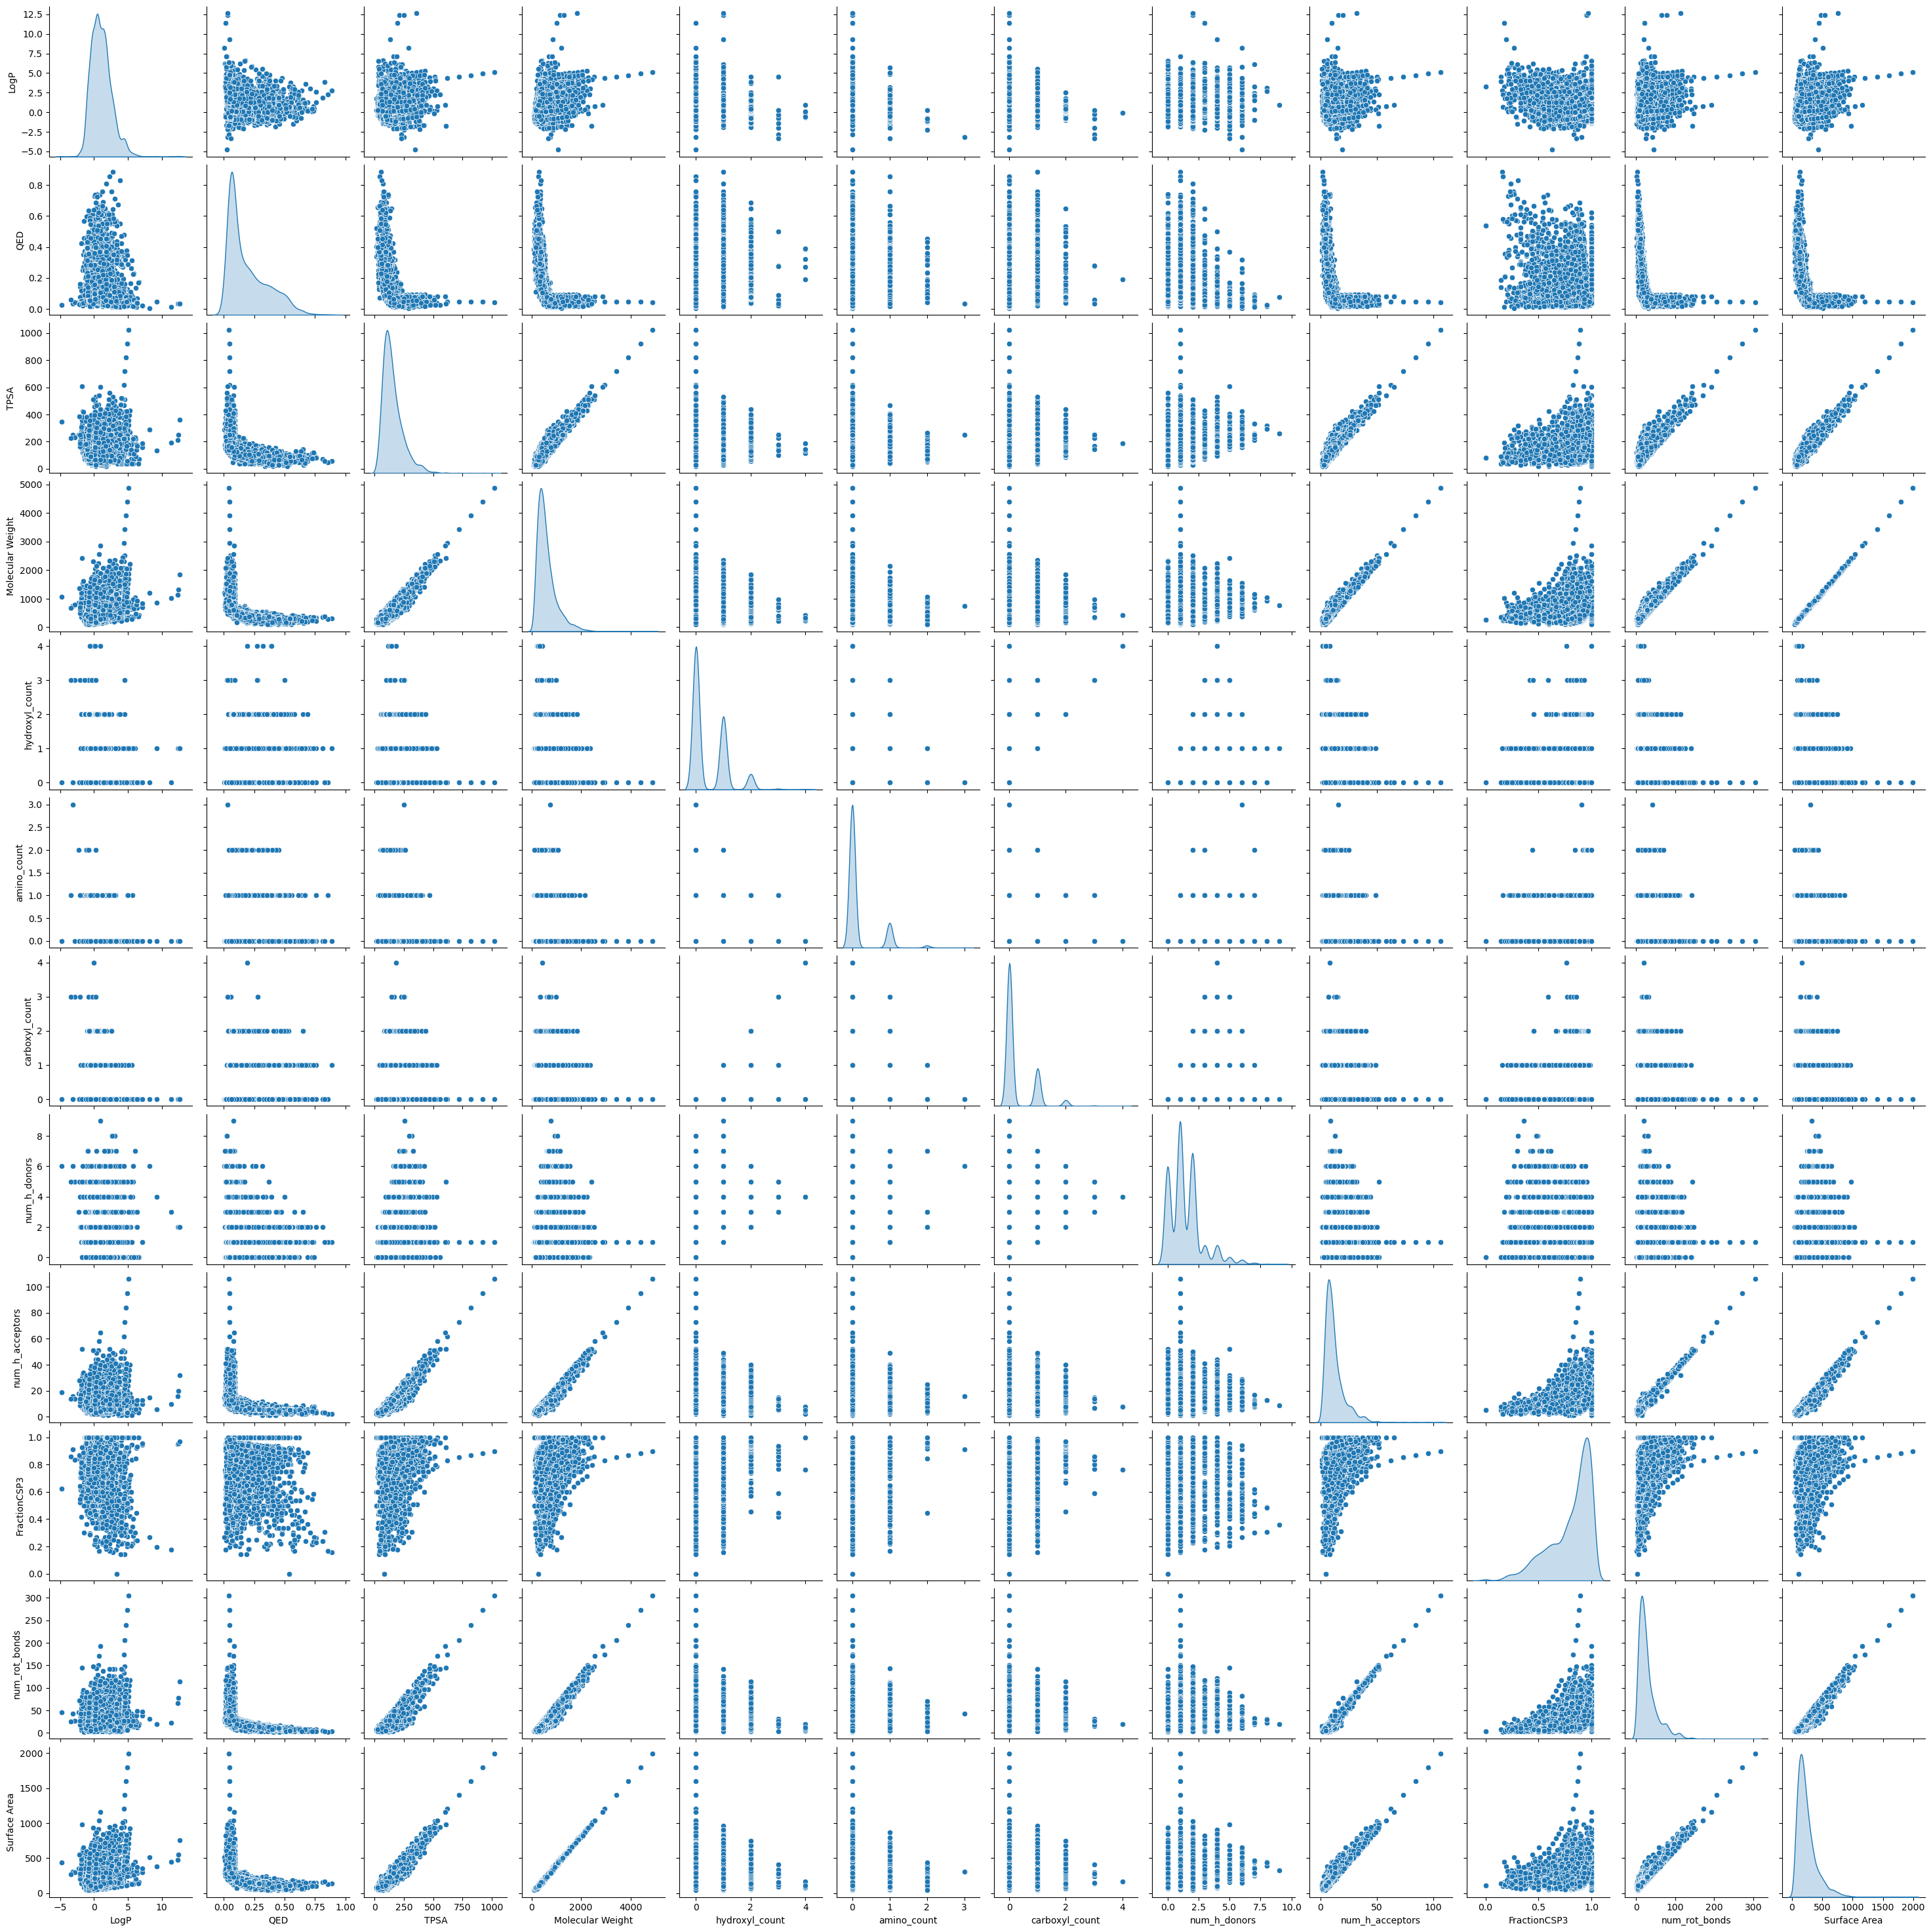

<Figure size 700x700 with 0 Axes>

In [18]:
sns.pairplot(linker[['LogP', 'QED', 'TPSA', 'Molecular Weight', 
                     'hydroxyl_count', 'amino_count', 'carboxyl_count', 'num_h_donors', 'num_h_acceptors', 'FractionCSP3', 'num_rot_bonds', 'Surface Area']], diag_kind='kde')
plt.figure(figsize = (7, 7))
plt.show()

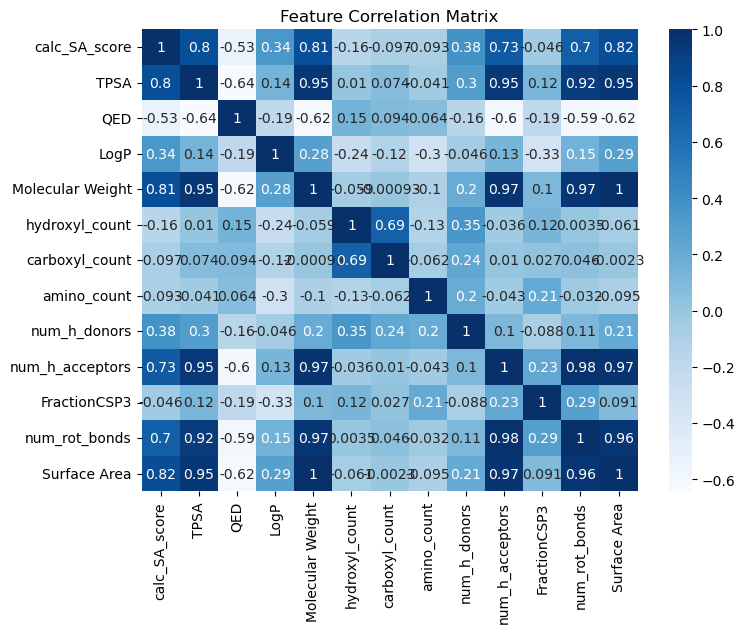

In [19]:
# Plot initial correlation matrix, exclude phosphate count 

plt.figure(figsize=(8,6))
sns.heatmap(linker[['calc_SA_score', 'TPSA', 'QED', 'LogP', 
                    'Molecular Weight', 'hydroxyl_count', 
                    'carboxyl_count', 'amino_count', 'num_h_donors', 'num_h_acceptors', 'FractionCSP3', 'num_rot_bonds', 'Surface Area']].corr(),
            annot=True, cmap='Blues') #excluding phosphate count since there are 0 everywhere
plt.title("Feature Correlation Matrix")
plt.show()

Strong Positive Correlations:
TPSA vs. MW,
TPSA vs. h_acceptors,
h_acceptors vs. MW,
num_rot_bonds vs. TPSA,
num_rot_bonds vs. h_acceptors,
num_rot_bonds vs. SA,
num_rot_bonds vs. MW,
SA vs. TPSA,
SA vs. MW,
SA vs. h_acceptors

Medium Positive Correlations:
carboxyl_count vs. hydroxyl_count,

Moderate Negative Correlations:
QED vs. TPSA,
num_h_acceptors vs. QED,
QED vs. MW,
num_rot_bonds vs. QED,
SA vs. QED